In [4]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [3]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0272EN-SkillsNetwork/labs/dataset/2016.csv"



### Downloading the dataset

Execute the following code to download the dataset in to the interface.


In [4]:
import requests

# Fetch the CSV file
response = requests.get(URL)

# Check if the request was successful
if response.status_code == 200:

    # Write the response content to a local file
    with open("dataset.csv", 'wb') as f:
        f.write(response.content)


In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

df = pd.read_csv('dataset.csv')

df.head()


,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.59,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [8]:
df.dtypes

Country                              str
Region                               str
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval            str
Economy (GDP per Capita)             str
Family                           float64
Health (Life Expectancy)             str
Freedom                              str
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

In [9]:
# Convert incorrect data types
cols_to_convert = [
    'Upper Confidence Interval',
    'Economy (GDP per Capita)',
    'Health (Life Expectancy)',
    'Freedom'
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [10]:
# Check missing values
missing = df.isnull().sum()

missing

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Lower Confidence Interval        4
Upper Confidence Interval        3
Economy (GDP per Capita)         2
Family                           0
Health (Life Expectancy)         3
Freedom                          1
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [11]:
# Fill missing values with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596
...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Benin,Sub-Saharan Africa,153,3.484,3.404,3.564,0.39499,0.10419,0.21028,0.39747,0.06681,0.20180,2.10812
153,Afghanistan,Southern Asia,154,3.360,3.288,3.432,0.38227,0.11037,0.17344,0.16430,0.07112,0.31268,2.14558
154,Togo,Sub-Saharan Africa,155,3.303,3.192,3.414,0.28123,0.00000,0.24811,0.34678,0.11587,0.17517,2.13540
155,Syria,Middle East and Northern Africa,156,3.069,2.936,3.202,0.74719,0.14866,0.62994,0.06912,0.17233,0.48397,0.81789


In [14]:
# Top 10 countries by Happiness Score
top10 = df.sort_values(by='Happiness Score', ascending=False).head(10)
top10

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592000,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590000,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669000,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575000,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475000,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596
5,Canada,North America,6,7.404,7.335,7.473000,1.44015,1.09610,0.82760,0.57370,0.31329,0.44834,2.70485
6,Netherlands,Western Europe,7,7.339,7.284,7.394000,1.46468,1.02912,0.81231,0.55211,0.29927,0.47416,2.70749
7,New Zealand,Australia and New Zealand,8,7.334,7.264,7.404000,1.36066,1.17278,0.83096,0.58147,0.41904,0.49401,2.47553
8,Australia,Australia and New Zealand,9,7.313,7.241,7.385000,1.44443,1.10476,0.85120,0.56837,0.32331,0.47407,2.54650
9,Sweden,Western Europe,10,7.291,7.227,5.472753,1.45181,1.08764,0.83121,0.58218,0.40867,0.38254,2.54734


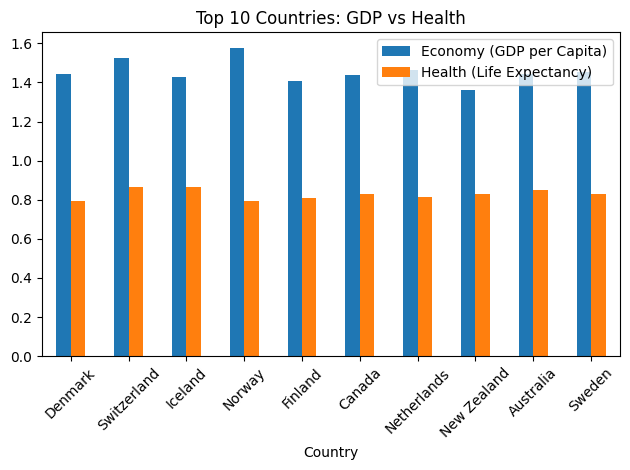

In [15]:
# Bar chart for GDP and Health
top10[['Country','Economy (GDP per Capita)','Health (Life Expectancy)']].set_index('Country').plot(kind='bar')
plt.title("Top 10 Countries: GDP vs Health")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Correlation
corr = df[['Economy (GDP per Capita)','Family','Health (Life Expectancy)','Freedom',
           'Trust (Government Corruption)','Generosity','Happiness Score']].corr()

corr

,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Happiness Score
Economy (GDP per Capita),1.000000,0.668984,0.825699,0.360998,0.286069,-0.022072,0.789625
Family,0.668984,1.000000,0.586163,0.450194,0.213561,0.089629,0.739252
Health (Life Expectancy),0.825699,0.586163,1.000000,0.348028,0.261928,0.069760,0.759471
Freedom,0.360998,0.450194,0.348028,1.000000,0.502030,0.361792,0.566807
Trust (Government Corruption),0.286069,0.213561,0.261928,0.502030,1.000000,0.305930,0.402032
Generosity,-0.022072,0.089629,0.069760,0.361792,0.305930,1.000000,0.156848
Happiness Score,0.789625,0.739252,0.759471,0.566807,0.402032,0.156848,1.000000


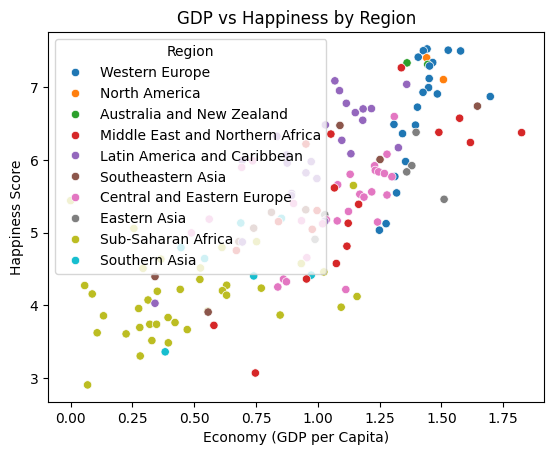

In [17]:
import seaborn as sns

sns.scatterplot(data=df, x='Economy (GDP per Capita)', y='Happiness Score', hue='Region')
plt.title("GDP vs Happiness by Region")
plt.show()

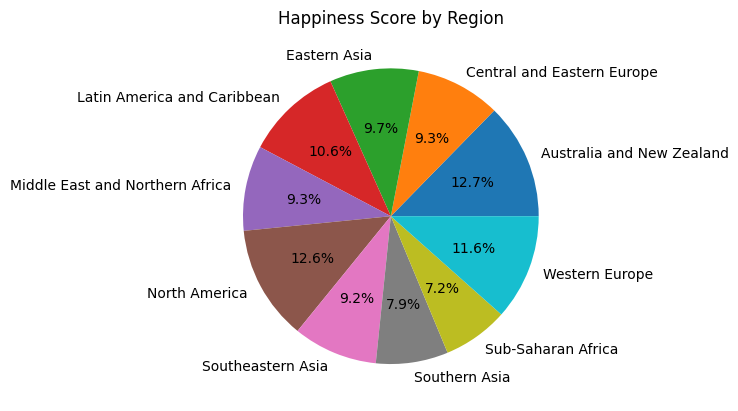

In [18]:
region_happiness = df.groupby('Region')['Happiness Score'].mean()

region_happiness.plot(kind='pie', autopct='%1.1f%%')
plt.title("Happiness Score by Region")
plt.ylabel('')
plt.show()

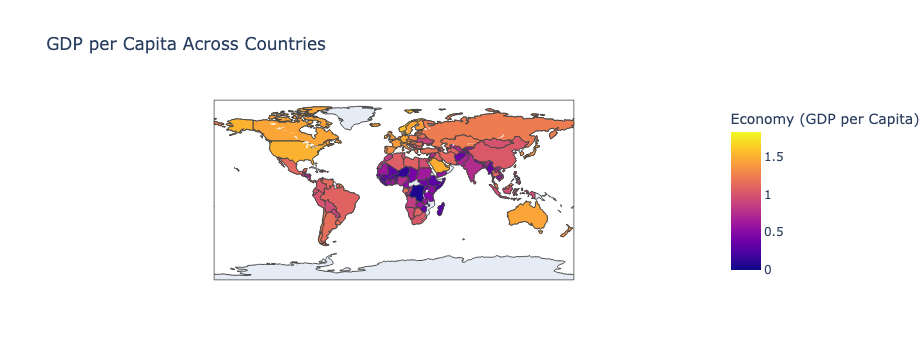

In [20]:
import plotly.express as px

fig = px.choropleth(
    df,
    locations="Country",
    locationmode="country names",
    color="Economy (GDP per Capita)",
    hover_name="Country",
    hover_data=["Health (Life Expectancy)"],
    title="GDP per Capita Across Countries"
)

fig.show()